<a href="https://colab.research.google.com/github/vidhya200707-arch/RUL---Vision/blob/main/rul__1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt",
    "/content/train_FD001.txt"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/test_FD001.txt",
    "/content/test_FD001.txt"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/RUL_FD001.txt",
    "/content/RUL_FD001.txt"
)

print("All 3 FD001 files downloaded successfully!")

All 3 FD001 files downloaded successfully!


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt', 'sample_data']


In [ ]:
import pandas as pd

# Column names for the FD001 dataset
columns = [
    'engine_id', 'cycle',
    'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
    'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8',
    'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
    'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

# Load training data
train_data = pd.read_csv(
    '/content/train_FD001.txt',
    sep=r'\s+',
    header=None,
    names=columns
)

# Load test data
test_data = pd.read_csv(
    '/content/test_FD001.txt',
    sep=r'\s+',
    header=None,
    names=columns
)

# Load actual RUL values
rul_data = pd.read_csv(
    '/content/RUL_FD001.txt',
    sep=r'\s+',
    header=None,
    names=['RUL']
)

print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
print("RUL data shape:", rul_data.shape)

Training data shape: (20631, 26)
Test data shape: (13096, 26)
RUL data shape: (100, 1)


In [ ]:
# Display the first 5 rows
train_data.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
# Check the information and data types
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [ ]:
# Check for missing values
train_data.isnull().sum()

,0
engine_id,0
cycle,0
setting_1,0
setting_2,0
setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [ ]:
# Calculate the maximum cycle for each engine
max_cycle = train_data.groupby('engine_id')['cycle'].max()

# Calculate RUL for every row
train_data['RUL'] = train_data.apply(
    lambda row: max_cycle[row['engine_id']] - row['cycle'],
    axis=1
)

# Check the result
train_data[['engine_id', 'cycle', 'RUL']].head(10)

,engine_id,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0
5,1,6,186.0
6,1,7,185.0
7,1,8,184.0
8,1,9,183.0
9,1,10,182.0


In [ ]:
train_data[train_data['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].tail()

,engine_id,cycle,RUL
187,1,188,4.0
188,1,189,3.0
189,1,190,2.0
190,1,191,1.0
191,1,192,0.0


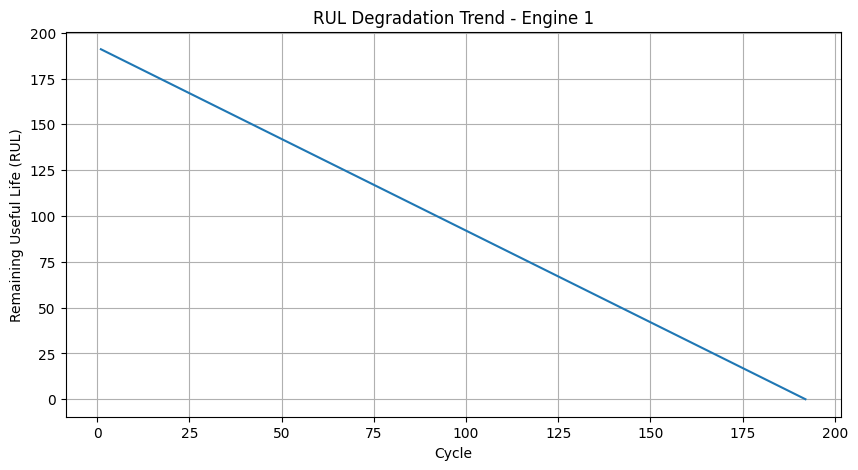

In [ ]:
import matplotlib.pyplot as plt

engine_1 = train_data[train_data['engine_id'] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1['cycle'], engine_1['RUL'])

plt.title('RUL Degradation Trend - Engine 1')
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (RUL)')
plt.grid(True)

plt.show()

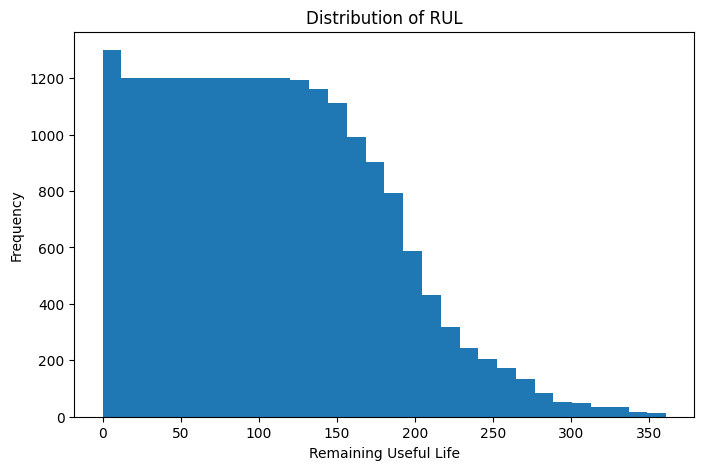

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(train_data['RUL'], bins=30)

plt.title('Distribution of RUL')
plt.xlabel('Remaining Useful Life')
plt.ylabel('Frequency')

plt.show()

In [ ]:
train_data.iloc[:, 6:27].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000
sensor_11,20631.0,47.541168,2.670874e-01,46.8500,47.3500,47.5100,47.7000,48.5300


In [ ]:
# Select sensor columns
sensor_columns = [col for col in train_data.columns if col.startswith('sensor_')]

# Input features
X = train_data[sensor_columns]

# Target
y = train_data['RUL']

print("Number of sensor features:", len(sensor_columns))
print("Input shape:", X.shape)
print("Target shape:", y.shape)

Number of sensor features: 21
Input shape: (20631, 21)
Target shape: (20631,)


In [ ]:
sensor_stats = train_data[sensor_columns].nunique()

print(sensor_stats)

sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
dtype: int64


In [ ]:
useful_sensors = sensor_stats[sensor_stats > 1].index.tolist()

print("Useful sensors:", useful_sensors)
print("Number of useful sensors:", len(useful_sensors))

Useful sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of useful sensors: 15


In [ ]:
X = train_data[useful_sensors]

print("Final input shape:", X.shape)

Final input shape: (20631, 15)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler()

# Fit and transform the training sensor data
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

# Display first 5 rows
X_scaled[:5]

Scaled data shape: (20631, 15)


array([[0.18373494, 0.40680183, 0.30975692, 1.        , 0.72624799,
        0.24242424, 0.109755  , 0.36904762, 0.63326226, 0.20588235,
        0.1996078 , 0.36398615, 0.33333333, 0.71317829, 0.7246617 ],
       [0.28313253, 0.4530194 , 0.35263336, 1.        , 0.62801932,
        0.21212121, 0.1002423 , 0.38095238, 0.76545842, 0.27941176,
        0.1628135 , 0.41131204, 0.33333333, 0.66666667, 0.73101353],
       [0.34337349, 0.36952256, 0.37052667, 1.        , 0.71014493,
        0.27272727, 0.14004308, 0.25      , 0.79530917, 0.22058824,
        0.17179275, 0.35744517, 0.16666667, 0.62790698, 0.62137531],
       [0.34337349, 0.25615871, 0.33119514, 1.        , 0.74074074,
        0.31818182, 0.12451763, 0.16666667, 0.8891258 , 0.29411765,
        0.17488905, 0.16660254, 0.33333333, 0.57364341, 0.66238608],
       [0.34939759, 0.25746675, 0.40462525, 1.        , 0.66827697,
        0.24242424, 0.14995962, 0.25595238, 0.74626866, 0.23529412,
        0.17473423, 0.40207772, 0.41666667, 

In [ ]:
import numpy as np

sequence_length = 50

X_sequences = []
y_sequences = []

# Create sequences separately for each engine
for engine_id in train_data['engine_id'].unique():

    engine_data = train_data[train_data['engine_id'] == engine_id]

    engine_X = scaler.transform(engine_data[useful_sensors])
    engine_y = engine_data['RUL'].values

    for i in range(len(engine_data) - sequence_length + 1):

        X_sequences.append(
            engine_X[i:i + sequence_length]
        )

        y_sequences.append(
            engine_y[i + sequence_length - 1]
        )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("X sequence shape:", X_sequences.shape)
print("y sequence shape:", y_sequences.shape)

X sequence shape: (15731, 50, 15)
y sequence shape: (15731,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_sequences,
    y_sequences,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Training targets:", y_train.shape)
print("Validation targets:", y_val.shape)

Training data: (12584, 50, 15)
Validation data: (3147, 50, 15)
Training targets: (12584,)
Validation targets: (3147,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

# Build Bi-LSTM model
model = Sequential([
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(50, 15)
    ),

    Dropout(0.2),

    Bidirectional(
        LSTM(32, return_sequences=False)
    ),

    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,233 (325.13 KB)

 Trainable params: 83,233 (325.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - loss: 6048.6714 - mae: 59.6067 - val_loss: 3418.8960 - val_mae: 45.9386
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - loss: 3354.5049 - mae: 46.5165 - val_loss: 3256.7280 - val_mae: 46.0185
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 3327.7156 - mae: 46.6337 - val_loss: 3254.3657 - val_mae: 45.9276
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - loss: 3331.2029 - mae: 46.6958 - val_loss: 3257.1042 - val_mae: 46.0335
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 3284.5808 - mae: 46.1600 - val_loss: 2130.0852 - val_mae: 34.0606
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 1676.7576 - mae: 29.1958 - val_loss: 1292.6826 - val_mae: 26.3798
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 1304.0582 - mae: 26.3029 - val_loss: 1236.9521 - val_mae: 25.5544
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 1295.7318 - mae: 25.8227 - val_los

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict RUL on validation data
y_pred = model.predict(X_val).flatten()

# Calculate evaluation metrics
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Bi-LSTM Model Performance")
print("--------------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Bi-LSTM Model Performance
--------------------------
MAE  : 18.0382723428728
RMSE : 27.88537205907764
R²   : 0.761028654243793


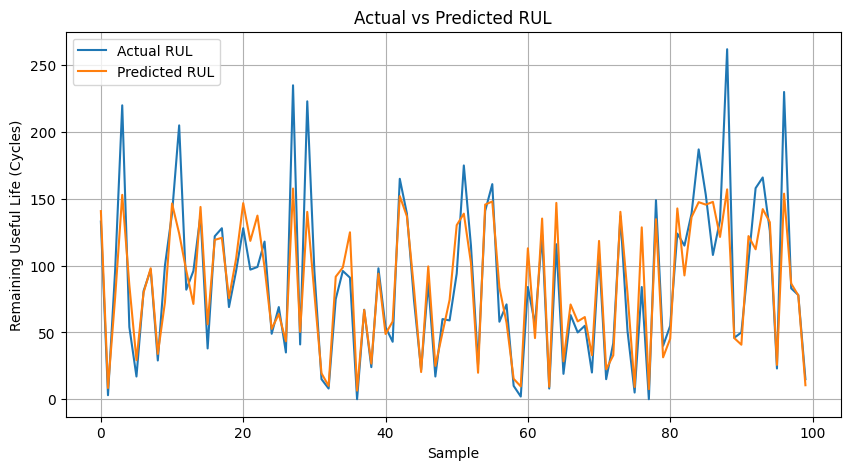

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_val[:100], label='Actual RUL')
plt.plot(y_pred[:100], label='Predicted RUL')

plt.title('Actual vs Predicted RUL')
plt.xlabel('Sample')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.grid(True)

plt.show()

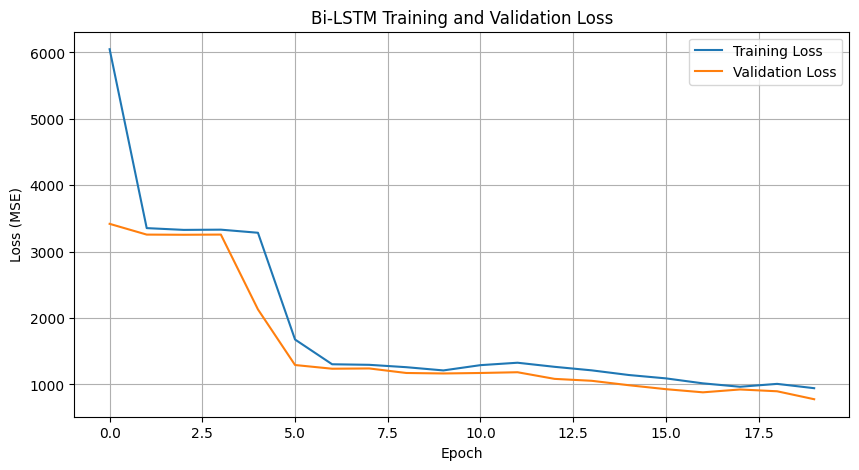

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Bi-LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Prepare test data

test_sequences = []
test_engine_ids = []

for engine_id in test_data['engine_id'].unique():

    engine_data = test_data[test_data['engine_id'] == engine_id]

    # Scale using the SAME scaler fitted on training data
    engine_X = scaler.transform(engine_data[useful_sensors])

    # Create the final 50-cycle sequence for this engine
    if len(engine_data) >= sequence_length:
        test_sequences.append(
            engine_X[-sequence_length:]
        )
        test_engine_ids.append(engine_id)

X_test = np.array(test_sequences)

print("Test sequence shape:", X_test.shape)
print("Number of test engines:", len(test_engine_ids))

Test sequence shape: (93, 50, 15)
Number of test engines: 93


In [ ]:
# Predict RUL for the test engines
y_test_pred = model.predict(X_test).flatten()

print("Number of predictions:", len(y_test_pred))
print("\nFirst 10 predicted RUL values:")
print(y_test_pred[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Number of predictions: 93

First 10 predicted RUL values:
[ 63.218266  76.10597   93.60959  114.47279  109.60565   75.68263
 133.09154   78.24823   90.244064  84.72413 ]


In [ ]:
# Prepare test sequences for ALL 100 engines

test_sequences = []
test_engine_ids = []

for engine_id in test_data['engine_id'].unique():

    engine_data = test_data[test_data['engine_id'] == engine_id]

    # Scale using the same scaler fitted on training data
    engine_X = scaler.transform(engine_data[useful_sensors])

    # Use the available data
    if len(engine_data) >= sequence_length:
        sequence = engine_X[-sequence_length:]
    else:
        # If the engine has fewer than 50 cycles,
        # pad the beginning by repeating the first observation
        padding = np.repeat(
            engine_X[0:1],
            sequence_length - len(engine_X),
            axis=0
        )

        sequence = np.vstack([padding, engine_X])

    test_sequences.append(sequence)
    test_engine_ids.append(engine_id)

X_test = np.array(test_sequences)

print("Test sequence shape:", X_test.shape)
print("Number of test engines:", len(test_engine_ids))

Test sequence shape: (100, 50, 15)
Number of test engines: 100


In [ ]:
# Predict RUL for all 100 test engines

y_test_pred = model.predict(X_test).flatten()

print("Number of predictions:", len(y_test_pred))
print("First 10 predictions:")
print(y_test_pred[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Number of predictions: 100
First 10 predictions:
[140.3822   125.6177    63.218266  76.10597   93.60959  114.47279
 109.60565   75.68263  133.09154   78.24823 ]


In [ ]:
# Actual RUL values
y_test_actual = rul_data['RUL'].values

# Final test metrics
test_mae = mean_absolute_error(y_test_actual, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_r2 = r2_score(y_test_actual, y_test_pred)

print("Final Test Set Performance")
print("--------------------------")
print("MAE  :", test_mae)
print("RMSE :", test_rmse)
print("R²   :", test_r2)

Final Test Set Performance
--------------------------
MAE  : 14.905180931091309
RMSE : 20.92876231507768
R²   : 0.7463542819023132


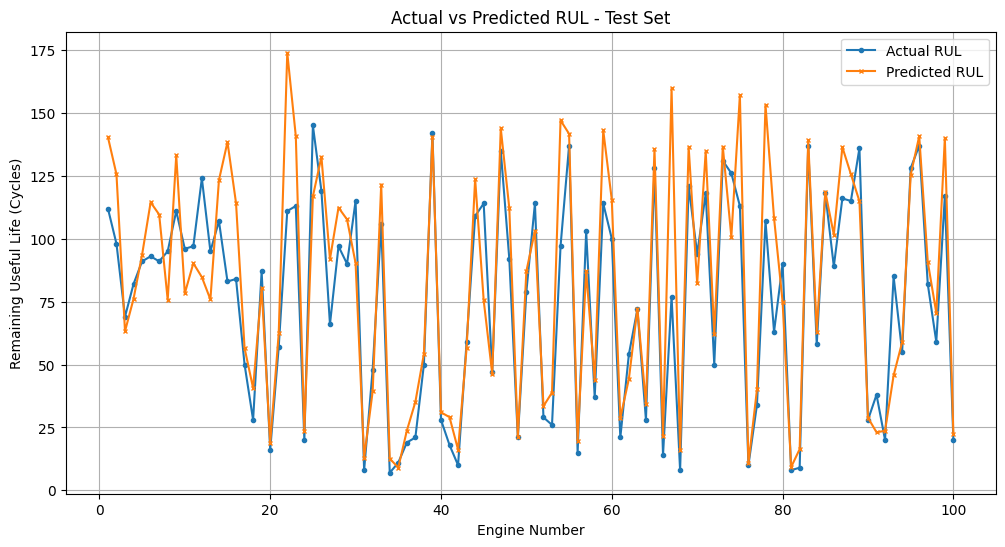

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    range(1, 101),
    y_test_actual,
    label='Actual RUL',
    marker='o',
    markersize=3
)

plt.plot(
    range(1, 101),
    y_test_pred,
    label='Predicted RUL',
    marker='x',
    markersize=3
)

plt.title('Actual vs Predicted RUL - Test Set')
plt.xlabel('Engine Number')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.grid(True)

plt.show()

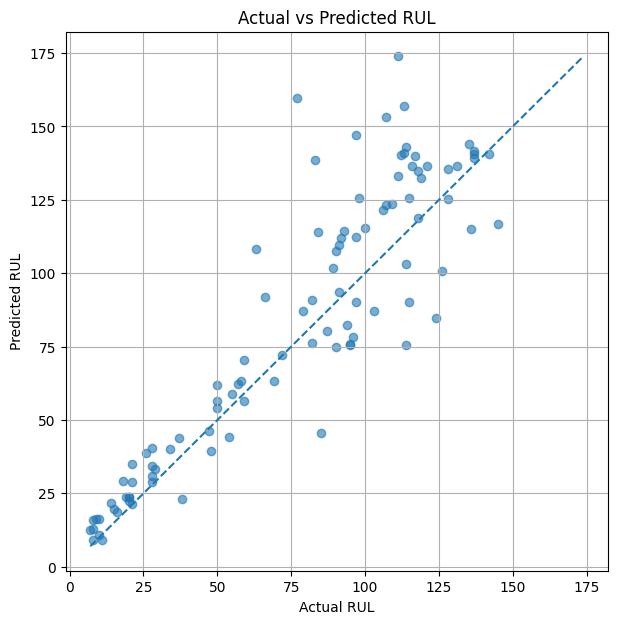

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test_actual, y_test_pred, alpha=0.6)

# Perfect prediction reference line
min_value = min(y_test_actual.min(), y_test_pred.min())
max_value = max(y_test_actual.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title('Actual vs Predicted RUL')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.grid(True)

plt.show()

In [ ]:
def classify_health(rul):
    if rul > 100:
        return "Healthy"
    elif rul > 50:
        return "Warning"
    else:
        return "Critical"


# Classify each test engine using predicted RUL
health_status = [classify_health(rul) for rul in y_test_pred]

# Create a result table
results = pd.DataFrame({
    'Engine': test_engine_ids,
    'Actual_RUL': y_test_actual,
    'Predicted_RUL': y_test_pred,
    'Health_Status': health_status
})

# Display first 10 results
results.head(10)

,Engine,Actual_RUL,Predicted_RUL,Health_Status
0,1,112,140.382202,Healthy
1,2,98,125.617699,Healthy
2,3,69,63.218266,Warning
3,4,82,76.105972,Warning
4,5,91,93.609589,Warning
5,6,93,114.472794,Healthy
6,7,91,109.605652,Healthy
7,8,95,75.682632,Warning
8,9,111,133.091537,Healthy
9,10,96,78.248230,Warning


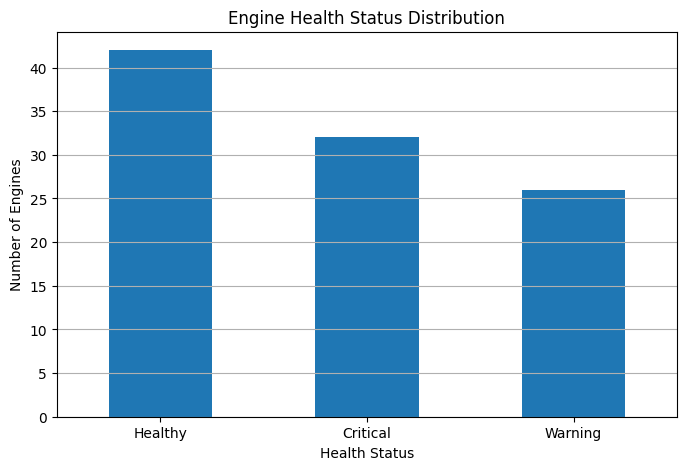

In [ ]:
plt.figure(figsize=(8, 5))

health_counts = results['Health_Status'].value_counts()
health_counts.plot(kind='bar')

plt.title('Engine Health Status Distribution')
plt.xlabel('Health Status')
plt.ylabel('Number of Engines')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
# Save the trained Bi-LSTM model
model.save('/content/rul_bilstm_model.keras')

print("Bi-LSTM model saved successfully!")

Bi-LSTM model saved successfully!


In [ ]:
import joblib

# Save the scaler used during preprocessing
joblib.dump(scaler, '/content/rul_scaler.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
import os

print(os.path.exists('/content/rul_bilstm_model.keras'))
print(os.path.exists('/content/rul_scaler.pkl'))

True
True


In [ ]:
# Prepare data for XGBoost

X_train_xgb = X_train[:, -1, :]
X_val_xgb = X_val[:, -1, :]

print("XGBoost training shape:", X_train_xgb.shape)
print("XGBoost validation shape:", X_val_xgb.shape)

XGBoost training shape: (12584, 15)
XGBoost validation shape: (3147, 15)


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(
    X_train_xgb,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [ ]:
# XGBoost predictions
y_xgb_pred = xgb_model.predict(X_val_xgb)

# XGBoost metrics
xgb_mae = mean_absolute_error(y_val, y_xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, y_xgb_pred))
xgb_r2 = r2_score(y_val, y_xgb_pred)

print("XGBoost Model Performance")
print("-------------------------")
print("MAE  :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R²   :", xgb_r2)

XGBoost Model Performance
-------------------------
MAE  : 23.477307239486407
RMSE : 34.27207107224498
R²   : 0.6390278950201841


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Bi-LSTM', 'XGBoost'],
    'MAE': [mae, xgb_mae],
    'RMSE': [rmse, xgb_rmse],
    'R²': [r2, xgb_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Bi-LSTM,18.038272,27.885372,0.761029
1,XGBoost,23.477307,34.272071,0.639028


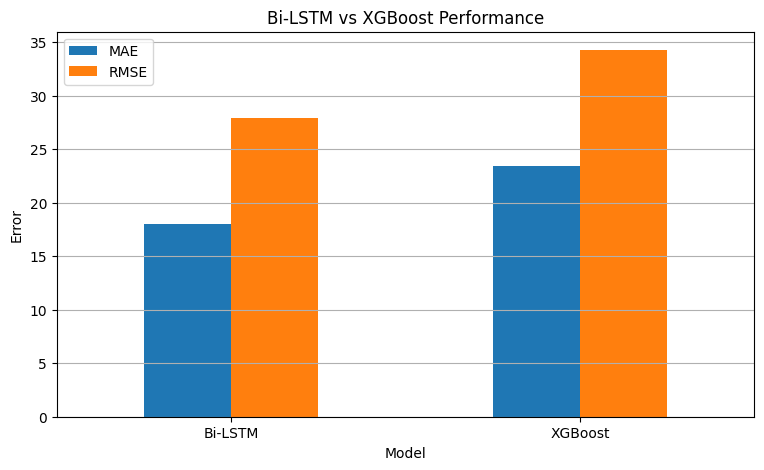

In [ ]:
comparison.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Bi-LSTM vs XGBoost Performance')
plt.xlabel('Model')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

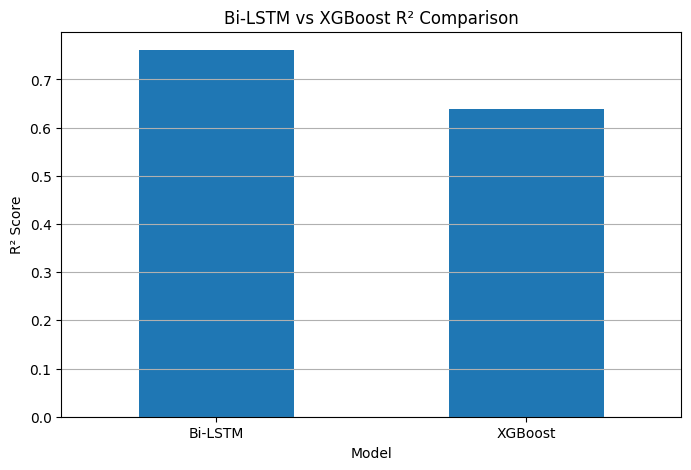

In [ ]:
comparison.set_index('Model')['R²'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Bi-LSTM vs XGBoost R² Comparison')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [ ]:
def calculate_health_percentage(rul):
    # Convert RUL to a percentage using 125 cycles as the reference
    health_percentage = (rul / 125) * 100

    # Keep the value between 0 and 100
    health_percentage = max(0, min(100, health_percentage))

    return health_percentage


def calculate_priority_score(rul):
    # Formula from the project PPT
    priority_score = ((125 - rul) / 125) * 100

    # Keep the value between 0 and 100
    priority_score = max(0, min(100, priority_score))

    return priority_score


# Apply to our test predictions
results['Health_Percentage'] = results['Predicted_RUL'].apply(
    calculate_health_percentage
)

results['Priority_Score'] = results['Predicted_RUL'].apply(
    calculate_priority_score
)

results.head(10)

,Engine,Actual_RUL,Predicted_RUL,Health_Status,Health_Percentage,Priority_Score
0,1,112,140.382202,Healthy,100.000000,0.000000
1,2,98,125.617699,Healthy,100.000000,0.000000
2,3,69,63.218266,Warning,50.574612,49.425388
3,4,82,76.105972,Warning,60.884778,39.115222
4,5,91,93.609589,Warning,74.887671,25.112329
5,6,93,114.472794,Healthy,91.578235,8.421765
6,7,91,109.605652,Healthy,87.684521,12.315479
7,8,95,75.682632,Warning,60.546106,39.453894
8,9,111,133.091537,Healthy,100.000000,0.000000
9,10,96,78.248230,Warning,62.598584,37.401416


In [ ]:
def detailed_maintenance_recommendation(rul):

    priority_score = calculate_priority_score(rul)

    if rul > 100:

        status = "Healthy"

        recommendation = (
            "ENGINE CONDITION: HEALTHY\n\n"
            "CURRENT ASSESSMENT:\n"
            "The predicted remaining useful life is above the "
            "healthy threshold.\n\n"

            "RECOMMENDED ACTION:\n"
            "• Continue normal operation.\n"
            "• Continue routine condition monitoring.\n"
            "• Follow the regular preventive maintenance schedule.\n"
            "• Continue monitoring sensor readings for abnormal changes.\n\n"

            "MAINTENANCE PRIORITY:\n"
            "LOW\n\n"

            f"PRIORITY SCORE: {priority_score:.2f}%"
        )

    elif rul > 50:

        status = "Warning"

        recommendation = (
            "ENGINE CONDITION: WARNING\n\n"
            "CURRENT ASSESSMENT:\n"
            "The predicted remaining useful life has entered "
            "the warning range and closer monitoring is required.\n\n"

            "RECOMMENDED ACTION:\n"
            "• Schedule preventive maintenance.\n"
            "• Inspect relevant engine components.\n"
            "• Increase monitoring of sensor readings.\n"
            "• Check for abnormal degradation patterns.\n"
            "• Plan maintenance before the RUL reaches the critical range.\n\n"

            "MAINTENANCE PRIORITY:\n"
            "MEDIUM\n\n"

            f"PRIORITY SCORE: {priority_score:.2f}%"
        )

    else:

        status = "Critical"

        recommendation = (
            "ENGINE CONDITION: CRITICAL\n\n"
            "CURRENT ASSESSMENT:\n"
            "The predicted remaining useful life is at or below "
            "the critical threshold.\n\n"

            "RECOMMENDED ACTION:\n"
            "• Perform immediate inspection.\n"
            "• Check critical engine components for degradation.\n"
            "• Review recent sensor measurements and degradation trends.\n"
            "• Schedule urgent maintenance intervention.\n"
            "• Consider repair or replacement based on inspection results.\n\n"

            "MAINTENANCE PRIORITY:\n"
            "HIGH\n\n"

            f"PRIORITY SCORE: {priority_score:.2f}%"
        )

    return status, recommendation

results['Maintenance_Recommendation'] = results['Predicted_RUL'].apply(lambda x: detailed_maintenance_recommendation(x)[1])

print(
    results[
        [
            'Engine',
            'Predicted_RUL',
            'Health_Status',
            'Health_Percentage',
            'Priority_Score',
            'Maintenance_Recommendation'
        ]
    ].head(10)
)

   Engine  Predicted_RUL Health_Status  Health_Percentage  Priority_Score  \
0       1     140.382202       Healthy         100.000000        0.000000   
1       2     125.617699       Healthy         100.000000        0.000000   
2       3      63.218266       Warning          50.574612       49.425388   
3       4      76.105972       Warning          60.884778       39.115222   
4       5      93.609589       Warning          74.887671       25.112329   
5       6     114.472794       Healthy          91.578235        8.421765   
6       7     109.605652       Healthy          87.684521       12.315479   
7       8      75.682632       Warning          60.546106       39.453894   
8       9     133.091537       Healthy         100.000000        0.000000   
9      10      78.248230       Warning          62.598584       37.401416   

                          Maintenance_Recommendation  
0  ENGINE CONDITION: HEALTHY\n\nCURRENT ASSESSMEN...  
1  ENGINE CONDITION: HEALTHY\n\nCURRENT AS

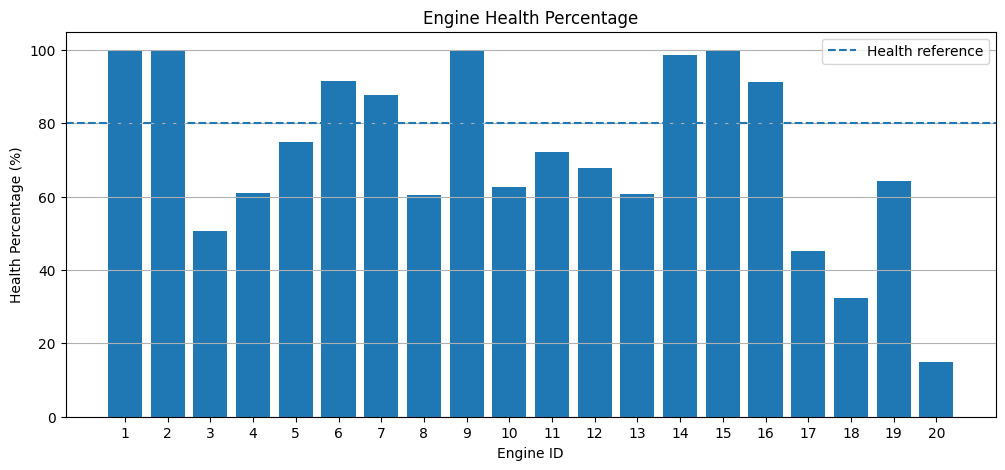

In [ ]:
engine_sample = results.head(20)

plt.figure(figsize=(12, 5))

plt.bar(
    engine_sample['Engine'].astype(str),
    engine_sample['Health_Percentage']
)

plt.axhline(
    80,
    linestyle='--',
    label='Health reference'
)

plt.title('Engine Health Percentage')
plt.xlabel('Engine ID')
plt.ylabel('Health Percentage (%)')
plt.legend()
plt.grid(axis='y')

plt.show()

In [ ]:
def get_engine_prediction(engine_id):

    engine_id = int(engine_id)

    # Get selected engine
    engine_data = test_data[
        test_data['engine_id'] == engine_id
    ].copy()

    if len(engine_data) == 0:
        raise ValueError("Engine ID not found")

    # Scale sensor data
    scaled_data = scaler.transform(
        engine_data[useful_sensors]
    )

    predictions = []
    cycles = []

    # CASE 1: Engine has 50 or more cycles
    if len(scaled_data) >= sequence_length:

        for i in range(sequence_length, len(scaled_data) + 1):

            sequence = scaled_data[
                i-sequence_length:i
            ]

            sequence = np.expand_dims(
                sequence,
                axis=0
            )

            prediction = model.predict(
                sequence,
                verbose=0
            )[0][0]

            predictions.append(float(prediction))

            cycles.append(
                int(engine_data['cycle'].iloc[i-1])
            )

    # CASE 2: Engine has fewer than 50 cycles
    else:

        padding = np.repeat(
            scaled_data[0:1],
            sequence_length - len(scaled_data),
            axis=0
        )

        sequence = np.vstack(
            [padding, scaled_data]
        )

        sequence = np.expand_dims(
            sequence,
            axis=0
        )

        prediction = model.predict(
            sequence,
            verbose=0
        )[0][0]

        predictions.append(float(prediction))

        cycles.append(
            int(engine_data['cycle'].iloc[-1])
        )

    predictions = np.array(predictions)

    # Final RUL prediction
    predicted_rul = float(predictions[-1])

    # Health status
    health_status = classify_health(
        predicted_rul
    )

    # Health percentage
    health_percentage = calculate_health_percentage(
        predicted_rul
    )

    # Priority score
    priority_score = calculate_priority_score(
        predicted_rul
    )

    # Maintenance recommendation
    health_status, recommendation = detailed_maintenance_recommendation(
    predicted_rul
    )

    return {
        "engine_id": engine_id,
        "predicted_rul": round(predicted_rul, 2),
        "health_percentage": round(health_percentage, 2),
        "health_status": health_status,
        "priority_score": round(priority_score, 2),
        "maintenance_recommendation": recommendation,
        "cycles": cycles,
        "predicted_rul_history": predictions.tolist()
    }

In [ ]:
def detailed_maintenance_recommendation(rul):

    priority_score = calculate_priority_score(rul)

    if rul > 100:

        status = "Healthy"

        recommendation = (
            "ENGINE CONDITION: HEALTHY\n\n"
            "CURRENT ASSESSMENT:\n"
            "The predicted remaining useful life is above the "
            "healthy threshold.\n\n"

            "RECOMMENDED ACTION:\n"
            "• Continue normal operation.\n"
            "• Continue routine condition monitoring.\n"
            "• Follow the regular preventive maintenance schedule.\n"
            "• Continue monitoring sensor readings for abnormal changes.\n\n"

            "MAINTENANCE PRIORITY:\n"
            "LOW\n\n"

            f"PRIORITY SCORE: {priority_score:.2f}%"
        )

    elif rul > 50:

        status = "Warning"

        recommendation = (
            "ENGINE CONDITION: WARNING\n\n"
            "CURRENT ASSESSMENT:\n"
            "The predicted remaining useful life has entered "
            "the warning range and closer monitoring is required.\n\n"

            "RECOMMENDED ACTION:\n"
            "• Schedule preventive maintenance.\n"
            "• Inspect relevant engine components.\n"
            "• Increase monitoring of sensor readings.\n"
            "• Check for abnormal degradation patterns.\n"
            "• Plan maintenance before the RUL reaches the critical range.\n\n"

            "MAINTENANCE PRIORITY:\n"
            "MEDIUM\n\n"

            f"PRIORITY SCORE: {priority_score:.2f}%"
        )

    else:

        status = "Critical"

        recommendation = (
            "ENGINE CONDITION: CRITICAL\n\n"
            "CURRENT ASSESSMENT:\n"
            "The predicted remaining useful life is at or below "
            "the critical threshold.\n\n"

            "RECOMMENDED ACTION:\n"
            "• Perform immediate inspection.\n"
            "• Check critical engine components for degradation.\n"
            "• Review recent sensor measurements and degradation trends.\n"
            "• Schedule urgent maintenance intervention.\n"
            "• Consider repair or replacement based on inspection results.\n\n"

            "MAINTENANCE PRIORITY:\n"
            "HIGH\n\n"

            f"PRIORITY SCORE: {priority_score:.2f}%"
        )

    return status, recommendation

In [ ]:
engine_result = get_engine_prediction(1)

print("========================================")
print("          RUL VISION REPORT")
print("========================================")

print("Engine ID         :", engine_result["engine_id"])
print("Predicted RUL     :", engine_result["predicted_rul"], "cycles")
print("Health Percentage :", engine_result["health_percentage"], "%")
print("Health Status     :", engine_result["health_status"])
print("Priority Score    :", engine_result["priority_score"], "%")

print("\n----------------------------------------")
print("MAINTENANCE RECOMMENDATION")
print("----------------------------------------")

print(engine_result["maintenance_recommendation"])

print("========================================")

          RUL VISION REPORT
Engine ID         : 1
Predicted RUL     : 140.38 cycles
Health Percentage : 100 %
Health Status     : Healthy
Priority Score    : 0 %

----------------------------------------
MAINTENANCE RECOMMENDATION
----------------------------------------
ENGINE CONDITION: HEALTHY

CURRENT ASSESSMENT:
The predicted remaining useful life is above the healthy threshold.

RECOMMENDED ACTION:
• Continue normal operation.
• Continue routine condition monitoring.
• Follow the regular preventive maintenance schedule.
• Continue monitoring sensor readings for abnormal changes.

MAINTENANCE PRIORITY:
LOW

PRIORITY SCORE: 0.00%


In [ ]:
# ============================================
# RUL VISION - FINAL DEMO UI
# ============================================

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np


def predict_engine(engine_id):

    # Call the previously defined get_engine_prediction function
    try:
        engine_result = get_engine_prediction(engine_id)
    except ValueError as e:
        return (
            "Error",
            "Error",
            "Error",
            f"Error: {e}",
            None,
            None,
            "Error"
        )

    predicted_rul = engine_result["predicted_rul"]
    health_percentage = engine_result["health_percentage"]
    health_status_str = engine_result["health_status"]
    priority_score = engine_result["priority_score"]
    maintenance_recommendation = engine_result["maintenance_recommendation"]
    cycles = engine_result["cycles"]
    predicted_rul_history = engine_result["predicted_rul_history"]

    # Determine status emoji and priority label for display
    if health_status_str == "Healthy":
        status_emoji = "🟢 HEALTHY"
        priority_label = "LOW"
    elif health_status_str == "Warning":
        status_emoji = "🟡 WARNING"
        priority_label = "MEDIUM"
    else:  # Critical
        status_emoji = "🔴 CRITICAL"
        priority_label = "HIGH"


    # Create fig1: Engine RUL Degradation Trend plot
    fig1 = plt.figure(figsize=(10, 5))
    plt.plot(cycles, predicted_rul_history, label='Predicted RUL')
    plt.title("Engine RUL Degradation Trend")
    plt.xlabel("Cycle")
    plt.ylabel("Remaining Useful Life")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.close(fig1) # Close the figure to prevent it from being displayed directly in the notebook


    # Create fig2: Health meter plot
    fig2 = plt.figure(figsize=(5, 5))
    ax = plt.gca()
    ax.pie(
        [health_percentage, 100 - health_percentage],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.30),
        colors=['#4CAF50', '#DDDDDD'] # Green for health, grey for remaining
    )
    ax.text(
        0,
        0,
        f"{health_percentage:.1f}%",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    ax.set_title("Engine Health")
    plt.tight_layout()
    plt.close(fig2) # Close the figure


    # Format outputs for Gradio
    rul_output = f"### {predicted_rul:.2f} cycles"
    health_output = f"### {health_percentage:.2f}%"
    priority_output = f"### {priority_score:.2f}% — {priority_label}"
    alert_output = f"""
## {status_emoji}

**Engine ID:** {engine_id}

**Predicted RUL:** {predicted_rul:.2f} cycles

**Priority Score:** {priority_score:.2f}%
"""
    # The maintenance_recommendation is already formatted markdown from get_engine_prediction
    recommendation_output = maintenance_recommendation


    return (
        rul_output,
        health_output,
        priority_output,
        alert_output,
        fig1,
        fig2,
        recommendation_output
    )


# ============================================
# GRADIO INTERFACE
# ============================================

engine_choices = [
    int(x)
    for x in sorted(test_data['engine_id'].unique())
]

with gr.Blocks(
    title="RUL Vision"
) as demo:

    gr.Markdown(
        """
# 🔧 RUL VISION

### AI-Based Predictive Maintenance System

Predict engine Remaining Useful Life and assess
engine health using Bi-LSTM.
"""
    )

    with gr.Row():

        engine_dropdown = gr.Dropdown(
            choices=engine_choices,
            value=engine_choices[0],
            label="Select Engine ID"
        )

        predict_button = gr.Button(
            "🔮 Predict RUL",
            variant="primary"
        )

    gr.Markdown("## 📊 Engine Health Assessment")

    with gr.Row():

        rul_display = gr.Markdown(
            "### --",
            label="Predicted RUL"
        )

        health_display = gr.Markdown(
            "### --",
            label="Health"
        )

        priority_display = gr.Markdown(
            "### --",
            label="Priority"
        )

    gr.Markdown("## 🚨 System Alert")

    alert_display = gr.Markdown(
        "Select an engine and click Predict RUL."
    )

    gr.Markdown("## 📈 Visualizations")

    with gr.Row():

        degradation_plot = gr.Plot(
            label="Engine Degradation"
        )

        health_plot = gr.Plot(
            label="Health Percentage"
        )

    gr.Markdown("## 🔧 Maintenance Recommendation")

    recommendation_display = gr.Markdown(
        "Prediction results will appear here."
    )

    predict_button.click(
        fn=predict_engine,
        inputs=engine_dropdown,
        outputs=[
            rul_display,
            health_display,
            priority_display,
            alert_display,
            degradation_plot,
            health_plot,
            recommendation_display
        ]
    )


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a2c751f2a488cef3e1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
